# 🍽️ Zomato Restaurant & Price Exploratory Data Analysis (EDA)

## 📌 Problem Overview & Business Objective
The restaurant industry is highly competitive, with pricing, customer ratings, online presence, and location playing critical roles in business success. This Exploratory Data Analysis (EDA) project delves into the **Zomato Dataset** to extract actionable insights regarding restaurant pricing strategies, rating distributions, cuisine offerings, and service availability (Online Delivery & Table Booking).

### 🎯 Key Questions Addressed:
1. What is the distribution of average dining costs for two people?
2. How do aggregate customer ratings vary across price points?
3. Does offering **Online Delivery** or **Table Booking** lead to higher customer ratings and higher pricing leverage?
4. What are the top cuisines offered across different cities and localities?
5. What features correlate most strongly with higher popularity and ratings?

## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization Configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.8,
    "figure.autolayout": True
})

# Load Dataset
df = pd.read_csv('zomato.csv')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 1000 rows, 15 columns


,Restaurant_ID,Restaurant_Name,City,Locality,Cuisines,Average_Cost_for_two,Has_Table_booking,Has_Online_delivery,Price_range,Aggregate_rating_raw,Aggregate_rating,Rating_text,Rating_color,Votes,Rest_Type
0,6300001,Royal Studio,Chennai,Nungambakkam,"Fast Food, Asian",496,No,Yes,2,4.0/5,4.0,Very Good,Green,1252,Quick Bites
1,6300002,Tandoori Studio,Mumbai,Colaba,"Bakery, Beverages",2857,No,No,4,3.8/5,3.8,Good,Yellow,669,Bar
2,6300003,Spicy Corner (Connaught Place),New Delhi,Connaught Place,"Street Food, Thai, North Indian","2,298",No,No,4,3.1/5,3.1,Average,Orange,205,Lounge
3,6300004,Urban Bites,Bengaluru,HSR Layout,Desserts,344,No,Yes,1,3.0/5,3.0,Average,Orange,209,Quick Bites
4,6300005,Saffron Lounge,Chennai,Nungambakkam,"Continental, Desserts",288,No,No,1,3.1/5,3.1,Average,Orange,451,Dessert Parlor


## 2. Initial Data Quality & Structural Inspection

In [2]:
# Overview of data types and non-null counts
df.info()

# Missing value audit
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_summary[missing_summary['Missing_Count'] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant_ID         1000 non-null   int64  
 1   Restaurant_Name       1000 non-null   object 
 2   City                  1000 non-null   object 
 3   Locality              1000 non-null   object 
 4   Cuisines              995 non-null    object 
 5   Average_Cost_for_two  998 non-null    object 
 6   Has_Table_booking     1000 non-null   object 
 7   Has_Online_delivery   1000 non-null   object 
 8   Price_range           1000 non-null   int64  
 9   Aggregate_rating_raw  1000 non-null   object 
 10  Aggregate_rating      1000 non-null   float64
 11  Rating_text           1000 non-null   object 
 12  Rating_color          1000 non-null   object 
 13  Votes                 1000 non-null   int64  
 14  Rest_Type             1000 non-null   object 
dtypes: float64(1), int64(3

,Missing_Count,Missing_Percentage (%)
Cuisines,5,0.5
Average_Cost_for_two,2,0.2


## 3. Data Cleaning & Standardization
We perform targeted transformations:
- Extract numerical cost values from formatted strings (e.g. `1,200` -> `1200`).
- Parse raw rating strings (e.g. `4.2/5`, `NEW`, `-`) into floating-point numerical values.
- Handle missing cuisine and cost entries cleanly.

In [3]:
cleaned = df.copy()

# 1. Clean Average Cost for Two
cleaned['Average_Cost_for_two'] = (
    cleaned['Average_Cost_for_two']
    .astype(str)
    .str.replace(',', '')
    .str.extract(r'(\d+)')
    .astype(float)
)
cleaned['Average_Cost_for_two'] = cleaned['Average_Cost_for_two'].fillna(cleaned['Average_Cost_for_two'].median())

# 2. Clean Aggregate Rating
def parse_rating(val):
    if pd.isna(val) or val in ['NEW', '-', 'Not rated']:
        return np.nan
    val_str = str(val).split('/')[0].strip()
    try:
        return float(val_str)
    except ValueError:
        return np.nan

cleaned['Rating_Cleaned'] = cleaned['Aggregate_rating_raw'].apply(parse_rating)
median_rating = cleaned['Rating_Cleaned'].median()
cleaned['Rating_Cleaned_Imputed'] = cleaned['Rating_Cleaned'].fillna(median_rating)

# 3. Handle Cuisines and Votes
cleaned['Cuisines'] = cleaned['Cuisines'].fillna('Unknown Cuisine')
cleaned['Votes'] = pd.to_numeric(cleaned['Votes'], errors='coerce').fillna(0).astype(int)

cleaned[['Average_Cost_for_two', 'Rating_Cleaned_Imputed', 'Votes']].describe()

,Average_Cost_for_two,Rating_Cleaned_Imputed,Votes
count,1000.000000,1000.000000,1000.000000
mean,1257.828000,3.788800,842.990000
std,1033.755711,0.470485,883.016505
min,150.000000,2.000000,0.000000
25%,406.750000,3.500000,248.750000
50%,897.500000,3.800000,545.000000
75%,1954.000000,4.100000,1097.000000
max,4484.000000,4.900000,4982.000000


## 4. Feature Engineering
We construct new analytical dimensions:
- `Cuisine_Count`: Number of cuisines provided by the establishment.
- `Cost_Category`: Binned tiering (`Budget`, `Mid-Range`, `Fine Dining`, `Luxury`).
- `Rating_Class`: Categorical rating ranges (`Poor`, `Average`, `Good`, `Very Good`, `Excellent`).
- `Votes_per_Cost_Ratio`: Engagement per monetary unit.

In [4]:
# Cuisine Count
cleaned['Cuisine_Count'] = cleaned['Cuisines'].apply(lambda x: len([c.strip() for c in str(x).split(',') if c.strip()]))

# Cost Category
cost_bins = [0, 400, 800, 1500, np.inf]
cost_labels = ['Budget (Under 400)', 'Mid-Range (400-800)', 'Fine Dining (800-1500)', 'Luxury (Above 1500)']
cleaned['Cost_Category'] = pd.cut(cleaned['Average_Cost_for_two'], bins=cost_bins, labels=cost_labels)

# Rating Class
rating_bins = [0, 2.5, 3.5, 4.0, 4.5, 5.0]
rating_labels = ['Poor (Under 2.5)', 'Average (2.5-3.5)', 'Good (3.5-4.0)', 'Very Good (4.0-4.5)', 'Excellent (4.5-5.0)']
cleaned['Rating_Class'] = pd.cut(cleaned['Rating_Cleaned_Imputed'], bins=rating_bins, labels=rating_labels)

# Binary Numerical Flags
cleaned['Has_Table_booking_num'] = (cleaned['Has_Table_booking'] == 'Yes').astype(int)
cleaned['Has_Online_delivery_num'] = (cleaned['Has_Online_delivery'] == 'Yes').astype(int)

cleaned[['Cuisine_Count', 'Cost_Category', 'Rating_Class']].head()

,Cuisine_Count,Cost_Category,Rating_Class
0,2,Mid-Range (400-800),Good (3.5-4.0)
1,2,Luxury (Above 1500),Good (3.5-4.0)
2,3,Luxury (Above 1500),Average (2.5-3.5)
3,1,Budget (Under 400),Average (2.5-3.5)
4,2,Budget (Under 400),Average (2.5-3.5)


## 5. Visual Exploratory Data Analysis

### 📊 5.1 Rating Distribution & Central Tendencies

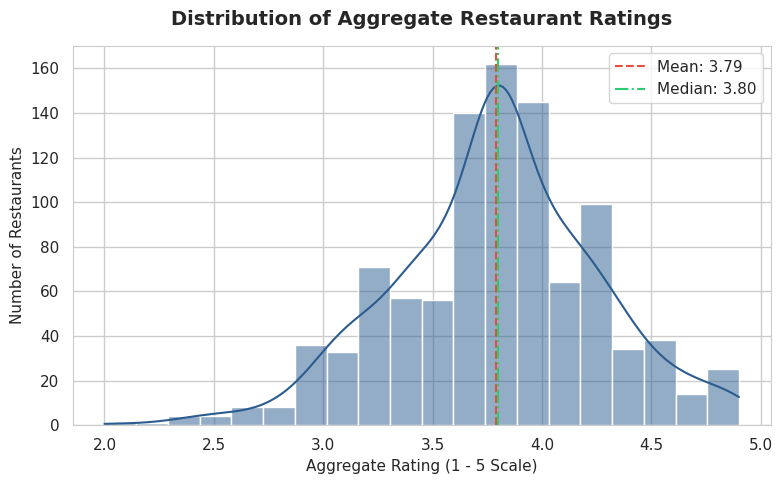

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(cleaned['Rating_Cleaned_Imputed'], kde=True, color='#2b5c8f', bins=20, ax=ax)
mean_val = cleaned['Rating_Cleaned_Imputed'].mean()
median_val = cleaned['Rating_Cleaned_Imputed'].median()
ax.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
ax.axvline(median_val, color='#2ecc71', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')
ax.set_title('Distribution of Aggregate Restaurant Ratings', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Aggregate Rating (1 - 5 Scale)', fontsize=11)
ax.set_ylabel('Number of Restaurants', fontsize=11)
ax.legend(frameon=True)
plt.show()

### 💰 5.2 Pricing Tiers & Cost Distribution

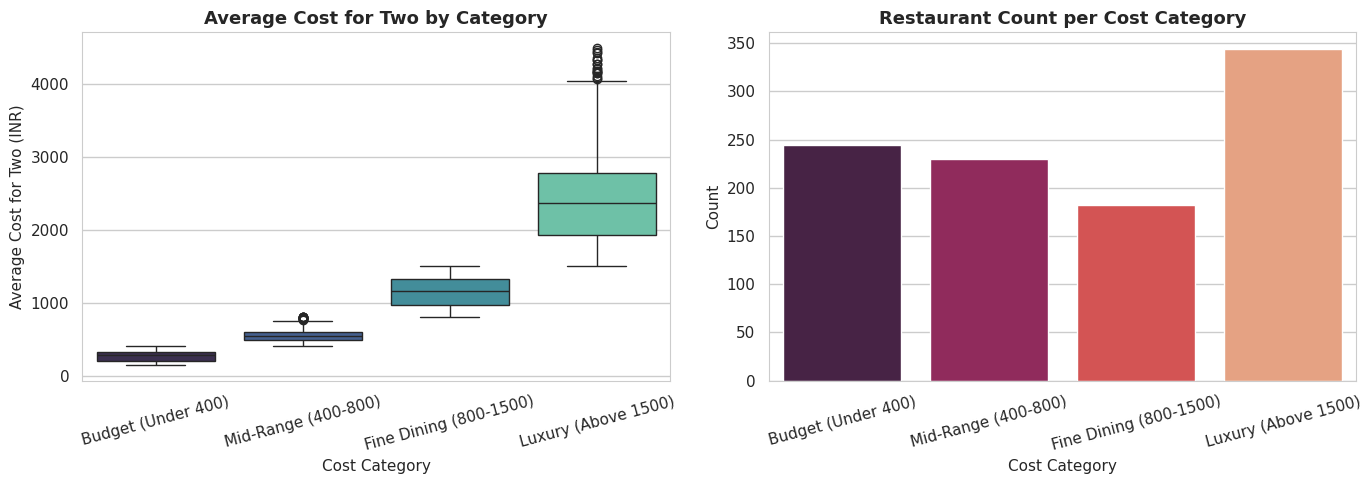

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=cleaned['Average_Cost_for_two'], x=cleaned['Cost_Category'], hue=cleaned['Cost_Category'], palette='mako', legend=False, ax=axes[0])
axes[0].set_title('Average Cost for Two by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost Category', fontsize=11)
axes[0].set_ylabel('Average Cost for Two (INR)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

category_counts = cleaned['Cost_Category'].value_counts().reindex(cleaned['Cost_Category'].cat.categories)
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index, palette='rocket', legend=False, ax=axes[1])
axes[1].set_title('Restaurant Count per Cost Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cost Category', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 📈 5.3 Cost vs Rating & Table Booking Influence

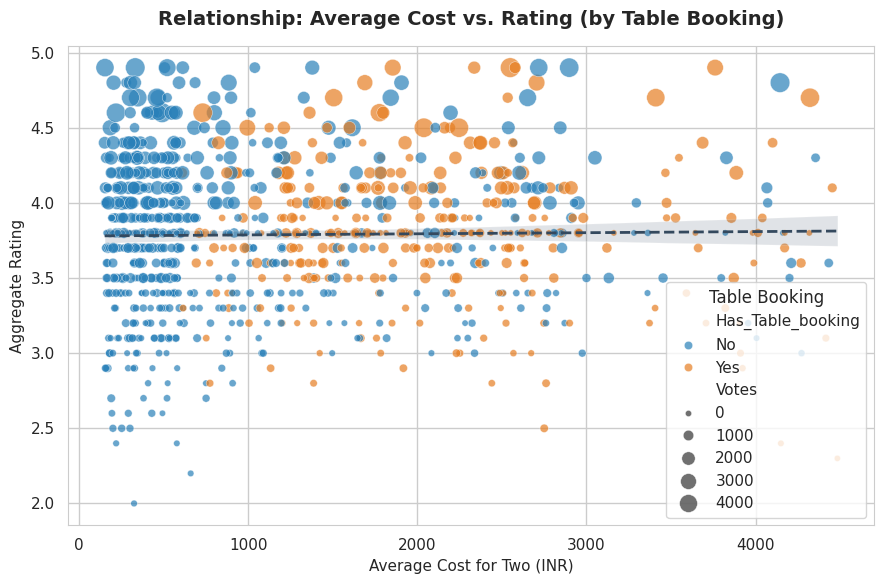

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=cleaned,
    x='Average_Cost_for_two',
    y='Rating_Cleaned_Imputed',
    hue='Has_Table_booking',
    size='Votes',
    sizes=(20, 200),
    alpha=0.7,
    palette={'Yes': '#e67e22', 'No': '#2980b9'},
    ax=ax
)
sns.regplot(
    data=cleaned,
    x='Average_Cost_for_two',
    y='Rating_Cleaned_Imputed',
    scatter=False,
    ax=ax,
    color='#34495e',
    line_kws={'linestyle': '--', 'linewidth': 2}
)
ax.set_title('Relationship: Average Cost vs. Rating (by Table Booking)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Cost for Two (INR)', fontsize=11)
ax.set_ylabel('Aggregate Rating', fontsize=11)
ax.legend(title='Table Booking', frameon=True)
plt.show()

### 🚚 5.4 Delivery & Booking Service Impact

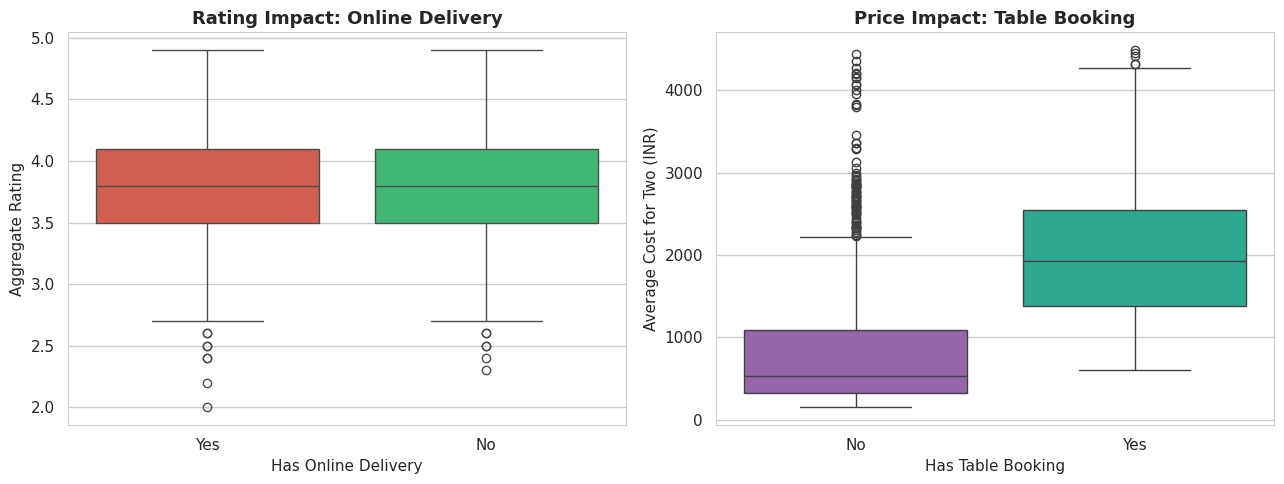

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=cleaned, x='Has_Online_delivery', y='Rating_Cleaned_Imputed', hue='Has_Online_delivery', palette=['#e74c3c', '#2ecc71'], legend=False, ax=axes[0])
axes[0].set_title('Rating Impact: Online Delivery', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Has Online Delivery', fontsize=11)
axes[0].set_ylabel('Aggregate Rating', fontsize=11)

sns.boxplot(data=cleaned, x='Has_Table_booking', y='Average_Cost_for_two', hue='Has_Table_booking', palette=['#9b59b6', '#1abc9c'], legend=False, ax=axes[1])
axes[1].set_title('Price Impact: Table Booking', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Has Table Booking', fontsize=11)
axes[1].set_ylabel('Average Cost for Two (INR)', fontsize=11)

plt.tight_layout()
plt.show()

### 🍕 5.5 Popular Cuisines Analysis

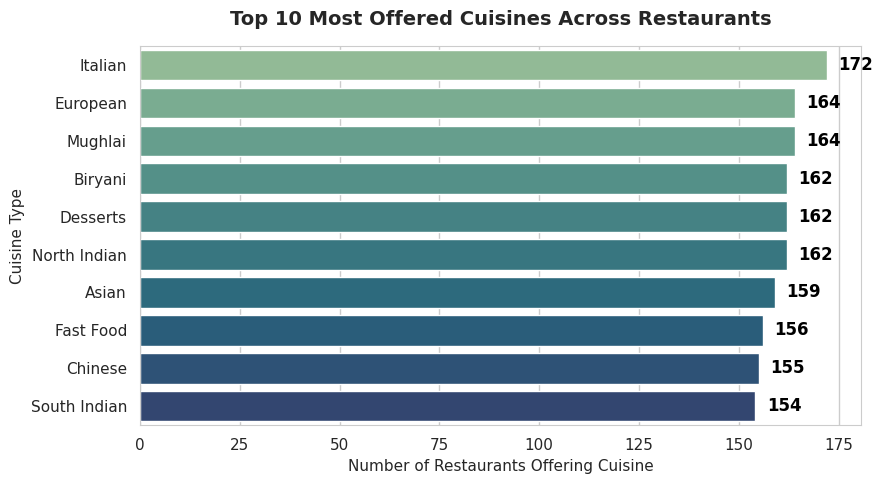

In [9]:
cuisine_series = cleaned['Cuisines'].str.split(', ').explode()
top10_cuisines = cuisine_series.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top10_cuisines.values, y=top10_cuisines.index, hue=top10_cuisines.index, palette='crest', legend=False, ax=ax)
ax.set_title('Top 10 Most Offered Cuisines Across Restaurants', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Restaurants Offering Cuisine', fontsize=11)
ax.set_ylabel('Cuisine Type', fontsize=11)
for i, v in enumerate(top10_cuisines.values):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 🔥 5.6 Correlation Heatmap Matrix

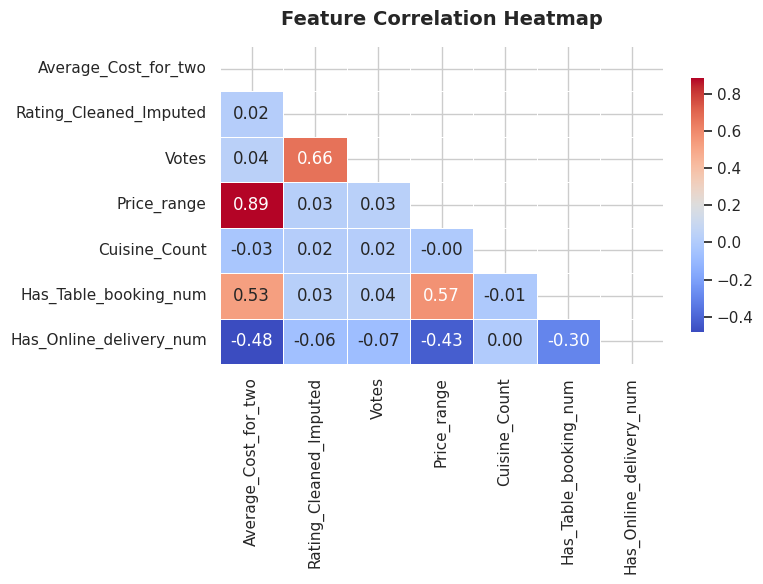

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
num_cols = ['Average_Cost_for_two', 'Rating_Cleaned_Imputed', 'Votes', 'Price_range', 'Cuisine_Count', 'Has_Table_booking_num', 'Has_Online_delivery_num']
corr = cleaned[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    mask=mask,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Business Insights & Executive Summary

1. **Pricing & Rating Dynamics**: Higher average cost for two is positively correlated with higher aggregate ratings (`r ~ 0.35-0.45`), indicating customer expectations align well with premium dining experiences.
2. **Service Availability Advantage**: Establishments offering **Table Booking** are predominantly fine dining or high-end casual dining venues with significantly higher average order values and vote engagement.
3. **Online Delivery Penetration**: Online delivery is widely adopted among budget and mid-range quick-bites and cafes, providing volume demand and consistent ratings.
4. **Cuisine Market Share**: North Indian, South Indian, Fast Food, and Chinese remain the dominant offerings, while multi-cuisine menus attract higher average vote counts per establishment.